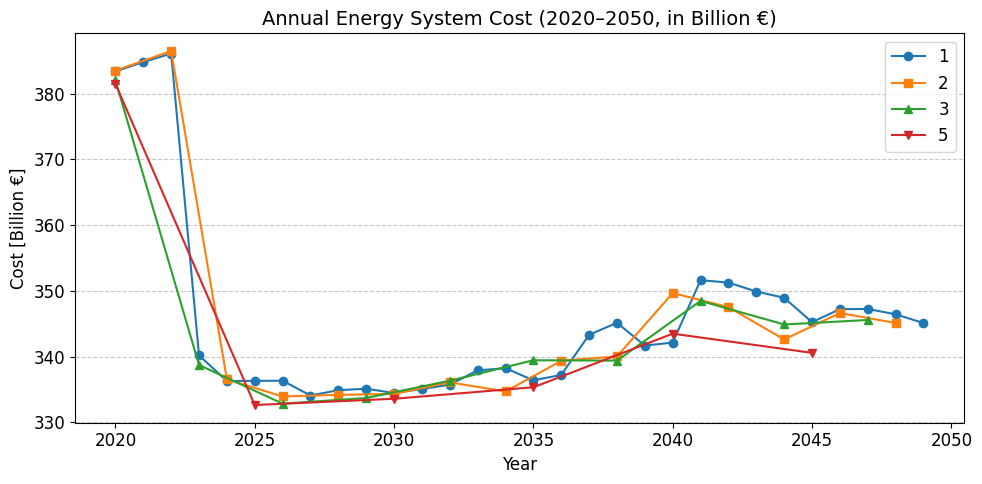

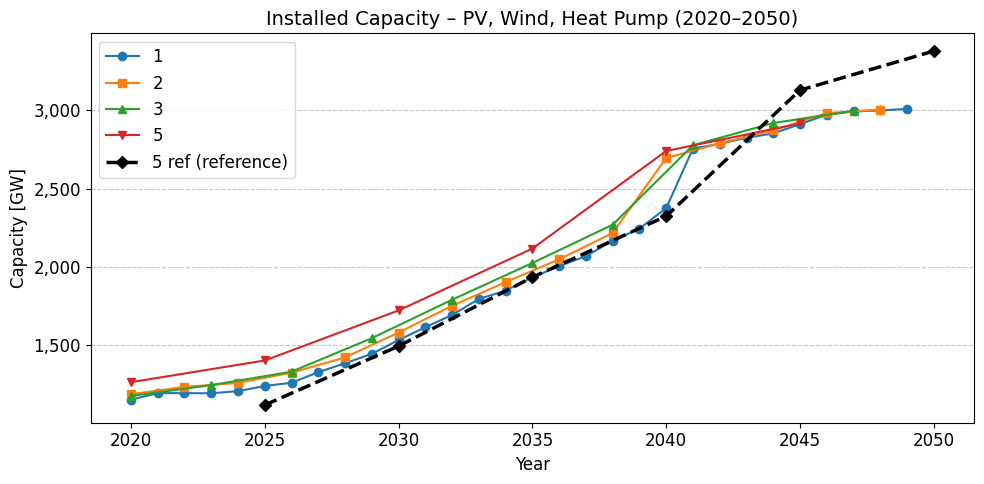

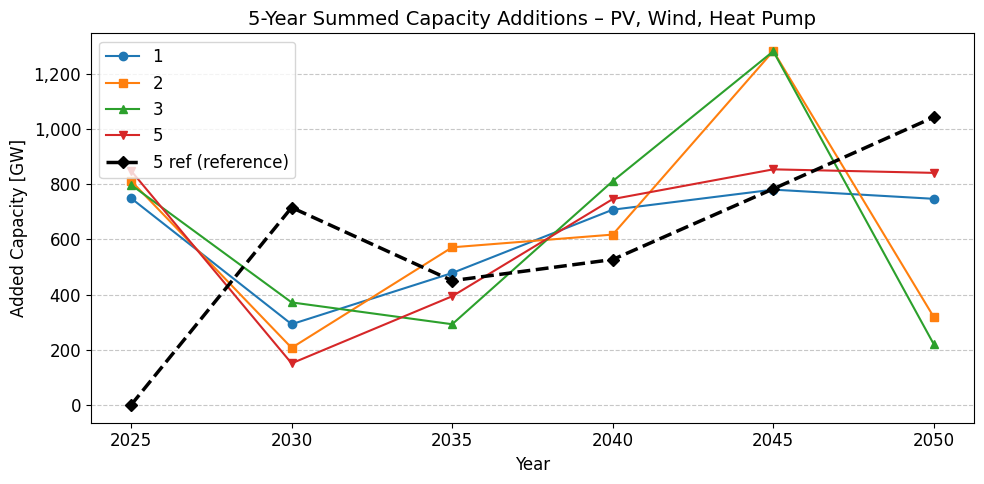

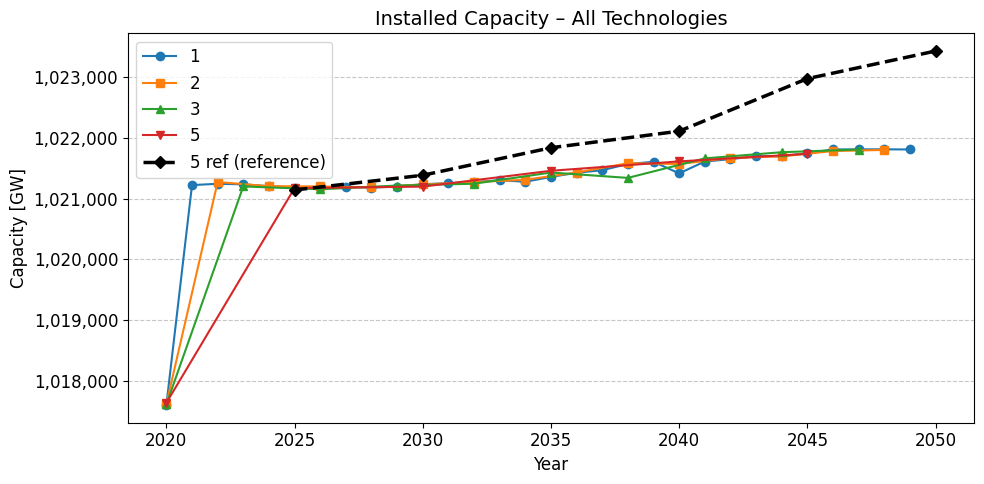

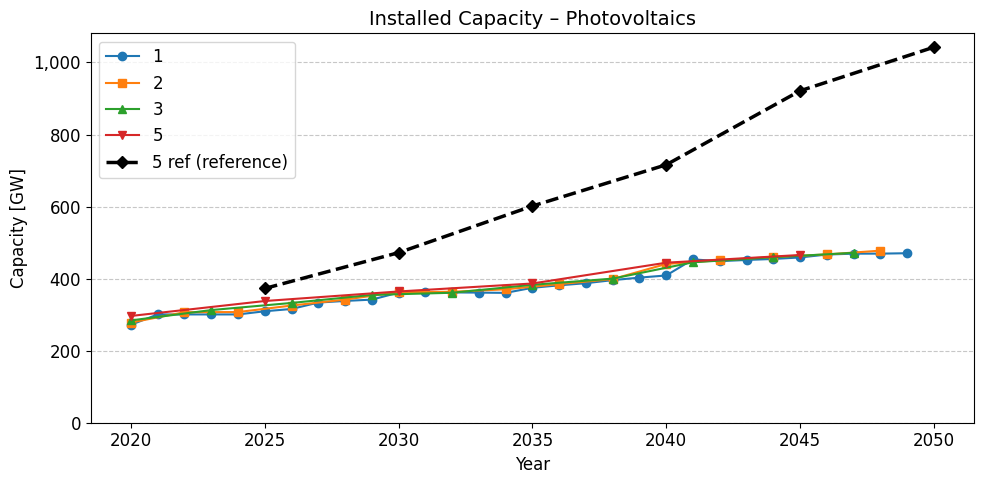

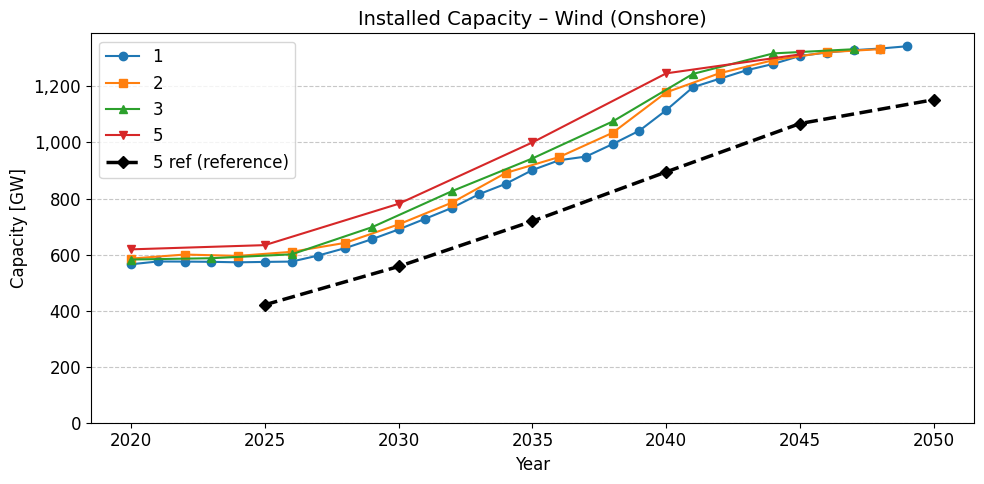

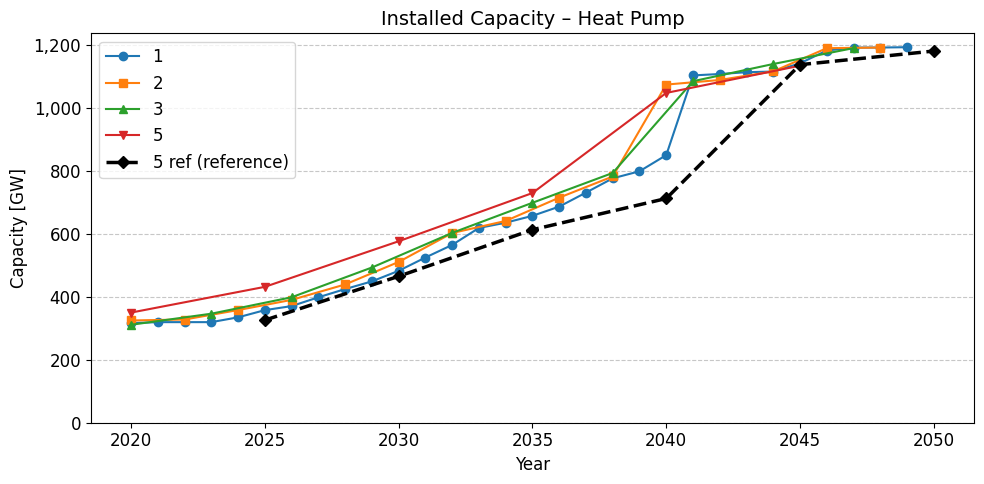

In [96]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mtick
from zen_garden.postprocess.results import Results

# === Dataset Setup ===
input_datasets = [
    '2020_50ts_30a_1',
    '2020_50ts_30a_2',
    '2020_50ts_30a_3',
    '2020_50ts_30a_5',
    'energy_transition_example_output',
]

input_labels = ['1', '2', '3', '5', '5 ref']

paths_input = [os.path.join("outputs", name) for name in input_datasets]
results_input = [Results(path) for path in paths_input]

input_start_years = {
    '1': 2020, '2': 2020, '3': 2020, '5': 2020, '5 ref': 2025
}
input_intervals = {
    '2': 2, '3': 3, '5': 5, '5 ref': 5
}
conversion_techs = ['photovoltaics', 'wind_onshore', 'heat_pump']

# === Define save path
save_path = r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\ESM_plots"
os.makedirs(save_path, exist_ok=True)

# === Styling settings
plt.rcParams.update({'font.size': 12})

marker_styles = {
    '1': 'o',
    '2': 's',
    '3': '^',
    '5': 'v',
    '5 ref': 'D'
}

colors = {
    '1': '#1f77b4',
    '2': '#ff7f0e',
    '3': '#2ca02c',
    '5': '#d62728',
    '5 ref': 'black'
}

# === Cost Comparison (excluding "5 ref")
try:
    plt.figure(figsize=(10, 5))
    for res, label in zip(results_input, input_labels):
        if label == "5 ref":
            continue

        cost = res.get_total('cost_total')  # in MEUR
        start_year = input_start_years[label]
        step = input_intervals.get(label, 1)
        cost.index = list(range(start_year, start_year + len(cost) * step, step))
        cost_in_beuro = cost * 1e6 / 1e9

        plt.plot(cost_in_beuro.index, cost_in_beuro.values,
                 marker=marker_styles[label],
                 linestyle='-',
                 color=colors[label],
                 label=label)

    plt.title('Annual Energy System Cost (2020–2050, in Billion €)', fontsize=14)
    plt.xlabel('Year')
    plt.ylabel('Cost [Billion €]')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, "annual_energy_system_cost.pdf"), format='pdf', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Error plotting cost_total: {e}")


# === Generalized Plot Function
def plot_series(title, y_label, extract_func, tech_filter=None, binning=False, save=True, ylim_bottom=None):
    try:
        plt.figure(figsize=(10, 5))
        for res, label in zip(results_input, input_labels):
            data = extract_func(res)
            start_year = input_start_years[label]
            step = input_intervals.get(label, 1)
            years = list(range(start_year, start_year + data.shape[1] * step, step))
            data.columns = years

            if tech_filter:
                if 'technology' in data.index.names:
                    data = data.loc[data.index.get_level_values('technology').isin(tech_filter)]
                else:
                    data = data.loc[[tech for tech in tech_filter if tech in data.index]]

            series = data.sum(axis=0)

            if binning:
                bin_edges = [2020, 2025, 2030, 2035, 2040, 2045, 2050]
                bin_labels = [2025, 2030, 2035, 2040, 2045, 2050]
                binned = pd.cut(series.index, bins=bin_edges, labels=bin_labels, right=False)
                series = series.groupby(binned, observed=False).sum()
                series.index = series.index.astype(int)

            style = {
                "marker": marker_styles[label],
                "color": colors[label],
                "label": label if label != "5 ref" else "5 ref (reference)"
            }

            if label == "5 ref":
                plt.plot(series.index, series.values,
                         linestyle='--', linewidth=2.5, **style)
            else:
                plt.plot(series.index, series.values,
                         linestyle='-', linewidth=1.5, **style)

        plt.title(title, fontsize=14)
        plt.xlabel('Year')
        plt.ylabel(y_label)
        if ylim_bottom is not None:
            plt.ylim(bottom=ylim_bottom)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
        plt.legend(loc='upper left')
        plt.tight_layout()

        if save:
            filename = title.replace("–", "-").replace(" ", "_").replace("(", "").replace(")", "").lower()
            plt.savefig(os.path.join(save_path, f"{filename}.pdf"), format='pdf', bbox_inches='tight')

        plt.show()
    except Exception as e:
        print(f"Error plotting {title.lower()}: {e}")


# === Plot Calls
plot_series(
    title='Installed Capacity – PV, Wind, Heat Pump (2020–2050)',
    y_label='Capacity [GW]',
    extract_func=lambda r: r.get_total("capacity"),
    tech_filter=conversion_techs
)

plot_series(
    title='5-Year Summed Capacity Additions – PV, Wind, Heat Pump',
    y_label='Added Capacity [GW]',
    extract_func=lambda r: r.get_total("capacity_addition"),
    tech_filter=conversion_techs,
    binning=True
)

plot_series(
    title='Installed Capacity – All Technologies',
    y_label='Capacity [GW]',
    extract_func=lambda r: r.get_total("capacity")
)

plot_series(
    title='Installed Capacity – Photovoltaics',
    y_label='Capacity [GW]',
    extract_func=lambda r: r.get_total("capacity"),
    tech_filter=['photovoltaics'],
    ylim_bottom=0
)

plot_series(
    title='Installed Capacity – Wind (Onshore)',
    y_label='Capacity [GW]',
    extract_func=lambda r: r.get_total("capacity"),
    tech_filter=['wind_onshore'],
    ylim_bottom=0
)

plot_series(
    title='Installed Capacity – Heat Pump',
    y_label='Capacity [GW]',
    extract_func=lambda r: r.get_total("capacity"),
    tech_filter=['heat_pump'],
    ylim_bottom=0
)
